<a href="https://colab.research.google.com/github/ericksbr/deduper/blob/reframe/grouper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# About Grouper

Grouper is a simple tool that groups **similar comments** in rulemaking submissions based on **word overlap** (not topic). It was designed to work with comments submitted to the Federal Register, but should work with any set of comments in a spreadsheet format.

## What it does
It reads a file of comments (CSV, Excel, or Parquet), groups similar ones together based on text similarity, and labels each comment as:
- **Ungrouped** — no other comment is similar enough (group size = 1)
- **Grouped - Identical** — exactly matches another comment after normalization
- **Grouped - Highly similar** — best match in group has Jaccard ≥ 0.90
- **Grouped - Moderately similar** — best match in group has Jaccard in (0.50, 0.90)

Note: Similarity is based on **wording overlap** (split into 5-word "shingles"), not semantic topic similarity. Two comments discussing the same topic may not group together if they use very different words.

## Groups and families
Each group is anchored on one representative comment, and every member is at least 50% similar to it. Groups whose representatives are at least 30% similar are linked into **families**, which can reveal coordinated campaigns that use several related templates.

## How to use
1. Collapse the "Setup" section. Click the play icon next to "1 cell hidden" to load the required packages.
2. Collapse the "Function Definitions" section. Click the play icon next to "18 cells hidden" to define all the actions this pipeline completes. Advanced users can review the functions.
3. Click play in the Upload File section. Select your comment file (CSV, Excel, or Parquet). Click play in the next cell to confirm the Column and ID (optional). If you need to change these, you can do so in the next cell.
4. Collapse "Pipeline Execution" and click play to run the grouping pipeline. Once running, you can expand and scroll to see progress at each stage.
5. Click play under the Interactive Explorer to browse groups of similar documents.
6. Download your file with new columns added for grouping analysis.

## Key concept
Jaccard similarity measures the fraction of shared 5-word chunks between two comments (0 = no overlap, 1 = identical text).

# Setup

In [78]:
# Install dependencies
import subprocess
import sys

packages = ['pandas', 'numpy', 'scipy', 'scikit-learn', 'openpyxl', 'pyarrow', 'nltk', 'matplotlib', 'tqdm']
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

# Imports
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from difflib import SequenceMatcher
import unicodedata
import re
import time
import gc
from ipywidgets import Dropdown, Output, IntText, VBox, HBox, HTML
from IPython.display import display, clear_output
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
import nltk
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)

# Google Colab file upload
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"✓ Setup complete ({'Google Colab' if IN_COLAB else 'Local Jupyter'})")

✓ Setup complete (Google Colab)


# Function Definitions (By Stage)

## Utilities

In [79]:
def load_file(filepath):
    """Load CSV/XLSX/Parquet file as DataFrame."""
    ext = Path(filepath).suffix.lower()
    if ext == '.csv':
        return pd.read_csv(filepath, dtype=str, keep_default_na=False)
    elif ext in ['.xlsx', '.xls']:
        return pd.read_excel(filepath, dtype=str, keep_default_na=False)
    elif ext == '.parquet':
        return pd.read_parquet(filepath).astype(str)
    else:
        raise ValueError(f"Unsupported file type: {ext}")

def detect_comment_column(df):
    """Auto-detect comment column (longest text on average)."""
    return max(df.columns, key=lambda c: df[c].astype(str).str.len().mean())

def detect_id_column(df):
    """Auto-detect ID column."""
    for col in ['id', 'ID', 'comment_id', 'document_id', 'tracking_number', 'Document ID']:
        if col in df.columns:
            return col
    return None

## Stage 1: Exact Match (Raw Text)

In [80]:
def exact_match_raw(texts):
    """Exact match on raw text."""
    df_raw = pd.DataFrame({'text': texts})
    exact_grp_raw = df_raw.groupby('text', sort=False).ngroup() + 1
    is_first_seen_raw = ~df_raw.duplicated('text', keep='first').values
    return exact_grp_raw.values, is_first_seen_raw

## Stage 2: Exact Match (Normalized Text)

In [81]:
def normalize_text(text: str) -> str:
    """Normalize text: NFKC, lowercase, NLTK tokenize, alphanumeric filter."""
    text = unicodedata.normalize('NFKC', text)
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if any(c.isalnum() for c in t)]
    text = ' '.join(tokens)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def exact_match_normalized(texts, is_first_seen_raw):
    """Exact match on normalized text (efficient: normalize first-seen-raw only)."""
    normalized_texts = np.empty(len(texts), dtype=object)
    raw_to_norm = {}

    # Normalize only first-seen-raw
    for idx in tqdm(np.where(is_first_seen_raw)[0], desc='Normalizing', unit='doc'):
        raw_text = texts[idx]
        norm_text = normalize_text(raw_text)
        normalized_texts[idx] = norm_text
        raw_to_norm[raw_text] = norm_text

    # Propagate to exact raw-text duplicates
    for idx in np.where(~is_first_seen_raw)[0]:
        raw_text = texts[idx]
        normalized_texts[idx] = raw_to_norm.get(raw_text, "")

    # Group on normalized text
    df_norm = pd.DataFrame({'text_normalized': normalized_texts})
    exact_grp_normalized = df_norm.groupby('text_normalized', sort=False).ngroup() + 1
    is_first_seen_normalized = ~df_norm.duplicated('text_normalized', keep='first').values

    return normalized_texts, exact_grp_normalized.values, is_first_seen_normalized

## Stage 3: Shingles & MinHash

In [82]:
def build_shingle_matrix(texts, k=5):
    """Build sparse shingle matrix (docs Ã— shingles)."""
    all_shingles_set = set()
    doc_shingles = []

    for text in texts:
        words = text.split()
        if len(words) >= k:
            shingles = {' '.join(words[i:i+k]) for i in range(len(words) - k + 1)}
        else:
            shingles = {text}
        doc_shingles.append(shingles)
        all_shingles_set.update(shingles)

    shingle_list = sorted(list(all_shingles_set))
    shingle_to_idx = {s: i for i, s in enumerate(shingle_list)}

    rows, cols, data = [], [], []
    for doc_idx, shingles in enumerate(doc_shingles):
        for shingle in shingles:
            rows.append(doc_idx)
            cols.append(shingle_to_idx[shingle])
            data.append(1)

    X = csr_matrix((data, (rows, cols)), shape=(len(doc_shingles), len(shingle_list)), dtype=np.uint8)
    return X

def minhash_signatures(X, num_perm=256, seed=42):
    """Vectorized MinHash over permutations (not shingles)."""
    n_docs = X.shape[0]
    assert np.all(np.diff(X.indptr) > 0), 'Every doc needs at least one shingle'

    rng = np.random.default_rng(seed)
    a = rng.integers(1, 2**63, size=num_perm, dtype=np.uint64) | np.uint64(1)
    b = rng.integers(0, 2**63, size=num_perm, dtype=np.uint64)

    ids = X.indices.astype(np.uint64)
    starts = X.indptr[:-1]
    sig = np.full((n_docs, num_perm), np.uint64(2**64 - 1), dtype=np.uint64)

    step = max(1, int(512e6 // (8 * max(1, len(ids)))))
    for p0 in tqdm(range(0, num_perm, step), desc='MinHash', unit='chunk'):
        p1 = min(num_perm, p0 + step)
        h = ids[:, None] * a[p0:p1] + b[p0:p1]
        h ^= h >> np.uint64(31)
        h *= np.uint64(0x9E3779B97F4A7C15)
        h ^= h >> np.uint64(29)
        sig[:, p0:p1] = np.minimum.reduceat(h, starts, axis=0)

    return sig

## Stage 4: LSH & Jaccard Verification

In [83]:
def choose_lsh_params(num_perm, min_threshold, target_recall):
    """Largest rows-per-band r (fewest junk candidates) whose S-curve still gives
    P(candidate | J = min_threshold) >= target_recall."""
    best = None
    for r in range(1, num_perm + 1):
        b = num_perm // r
        if 1 - (1 - min_threshold**r) ** b >= target_recall:
            best = (b, r)
    if best is None:
        raise ValueError('No (b, r) reaches the target recall; raise NUM_PERM or lower TARGET_RECALL')
    return best

def _pairs_for_groups(order, starts, sz, n):
    """All within-group pairs for many groups of identical size sz, vectorized, encoded lo*n+hi."""
    members = order[starts[:, None] + np.arange(sz)]          # (G, sz)
    i, j = np.triu_indices(sz, 1)
    p, q = members[:, i].ravel(), members[:, j].ravel()
    return np.minimum(p, q) * n + np.maximum(p, q)

def lsh_candidate_pairs(sig, b, r, max_bucket=500, big_degree=50, seed=42):
    """Band the signatures, bucket identical bands, and emit within-bucket pairs.
    Memory-safe: consolidates every 30M pairs."""
    n = sig.shape[0]
    rng = np.random.default_rng(seed + 1)
    mult = rng.integers(1, 2**63, size=r, dtype=np.uint64) | np.uint64(1)
    chunks, pending, n_sampled = [], 0, 0

    for k in tqdm(range(b), desc='LSH bands', unit='band'):
        key = (sig[:, k * r:(k + 1) * r] * mult).sum(axis=1, dtype=np.uint64)
        order = np.argsort(key, kind='stable').astype(np.int64)
        ks = key[order]
        starts = np.r_[0, np.flatnonzero(ks[1:] != ks[:-1]) + 1]
        sizes = np.diff(np.r_[starts, n])

        for sz in np.unique(sizes[sizes > 1]):
            grp_starts = starts[sizes == sz]
            if sz <= max_bucket:
                chunks.append(_pairs_for_groups(order, grp_starts, int(sz), n))
            else:
                for s0 in grp_starts:
                    n_sampled += 1
                    m = order[s0:s0 + sz]
                    p = np.repeat(m, big_degree)
                    q = m[rng.integers(0, sz, size=sz * big_degree)]
                    keep = p != q
                    p, q = p[keep], q[keep]
                    chunks.append(np.minimum(p, q) * n + np.maximum(p, q))
            pending += len(chunks[-1])

        if pending > 30_000_000:  # consolidate to bound memory
            chunks = [np.unique(np.concatenate(chunks))]
            pending = len(chunks[0])

    if not chunks:
        return np.empty(0, np.int32), np.empty(0, np.int32), n_sampled

    codes = np.unique(np.concatenate(chunks))
    return codes // n, codes % n, n_sampled

def exact_jaccard_batched(X, a, b, min_t, chunk=50_000):
    """Compute exact Jaccard in batches to avoid RAM spike."""
    verified_edges = []

    for chunk_start in range(0, len(a), chunk):
        chunk_end = min(chunk_start + chunk, len(a))
        chunk_a = a[chunk_start:chunk_end]
        chunk_b = b[chunk_start:chunk_end]

        # Compute Jaccard for this chunk
        sizes = np.diff(X.indptr).astype(np.int64)
        inter = np.asarray(X[chunk_a].multiply(X[chunk_b]).sum(axis=1)).ravel()
        jaccard = inter / (sizes[chunk_a] + sizes[chunk_b] - inter)

        # Keep only those >= min_t
        keep = jaccard >= min_t - 1e-9
        verified_edges.append((chunk_a[keep], chunk_b[keep], jaccard[keep]))

    if verified_edges:
        e1 = np.concatenate([e[0] for e in verified_edges]).astype(np.int32)
        e2 = np.concatenate([e[1] for e in verified_edges]).astype(np.int32)
        ej = np.concatenate([e[2] for e in verified_edges]).astype(np.float32)
        return e1, e2, ej
    else:
        return np.array([], dtype=np.int32), np.array([], dtype=np.int32), np.array([], dtype=np.float32)

## Stage 5: Connected Components

In [ ]:
def anchored_groups(n_docs, edge_a, edge_b, edge_j, threshold):
    """Greedy star clustering: highest-degree docs become centers; unassigned neighbors >= threshold join."""
    keep = edge_j >= threshold - 1e-9
    a, b, j = edge_a[keep], edge_b[keep], edge_j[keep]
    src = np.concatenate([a, b])
    dst = np.concatenate([b, a])
    w = np.concatenate([j, j])
    order = np.argsort(src, kind='stable')
    dst, w = dst[order], w[order]
    indptr = np.zeros(n_docs + 1, dtype=np.int64)
    np.cumsum(np.bincount(src, minlength=n_docs), out=indptr[1:])
    del src, order
    center_order = np.argsort(-np.diff(indptr), kind='stable')

    anchor = np.full(n_docs, -1, dtype=np.int64)
    anchor_j = np.zeros(n_docs, dtype=np.float32)
    for c in tqdm(center_order, desc='Anchoring', unit='doc'):
        if anchor[c] != -1:
            continue
        anchor[c] = c
        anchor_j[c] = 1.0
        s, e = indptr[c], indptr[c + 1]
        nb = dst[s:e]
        free = anchor[nb] == -1
        anchor[nb[free]] = c
        anchor_j[nb[free]] = w[s:e][free]
    return anchor, anchor_j

def group_ids_from_anchor(anchor):
    """Number groups 1..G, largest first; each doc takes its anchor's number."""
    _, inverse, sizes = np.unique(anchor, return_inverse=True, return_counts=True)
    rank_order = np.argsort(-sizes, kind='stable')
    rank = np.empty(len(sizes), dtype=np.int32)
    rank[rank_order] = np.arange(1, len(sizes) + 1, dtype=np.int32)
    return rank[inverse]


## Stage 6: Results Summary

In [85]:
def assign_group_label(is_identical, max_j_in_group, group_size, HIGH_J=0.90, GROUP_J=0.50):
    """Assign group label based on similarity to best match in group."""
    if group_size == 1:
        return 'Ungrouped'
    elif is_identical:
        return 'Grouped - Identical'
    elif max_j_in_group >= HIGH_J:
        return 'Grouped - Highly similar'
    elif max_j_in_group > GROUP_J:
        return 'Grouped - Moderately similar'
    else:
        # Should not happen if grouping was done at GROUP_J threshold
        return 'Ungrouped'

## Stage 7: Campaign Hierarchy

In [86]:
def get_jaccard_similarity(norm_text1, norm_text2, k=5):
    """Jaccard similarity on k-word shingles (assumes already-normalized text).

    Args:
        norm_text1, norm_text2: already normalized text (whitespace-separated words)
        k: shingle size in words

    Returns:
        Jaccard similarity in [0, 1]
    """
    words1 = norm_text1.split()
    words2 = norm_text2.split()

    # For documents with < k words, use whole text as one shingle (consistent with build_shingle_matrix)
    if len(words1) < k:
        shingles1 = {' '.join(words1)} if words1 else {''}
    else:
        shingles1 = {' '.join(words1[i:i+k]) for i in range(len(words1) - k + 1)}

    if len(words2) < k:
        shingles2 = {' '.join(words2)} if words2 else {''}
    else:
        shingles2 = {' '.join(words2[i:i+k]) for i in range(len(words2) - k + 1)}

    intersection = len(shingles1 & shingles2)
    union = len(shingles1 | shingles2)
    return intersection / union if union > 0 else 0.0


## Stage 8: Interactive Explorer

In [87]:
BUCKET_LABELS = {
    'near_exact': 'Near-Exact (J > 0.95)',
    'high_var': 'High Similarity (0.80 - 0.95)',
    'med_var': 'Medium Similarity (0.60 - 0.80)',
    'low_var': 'Low Similarity (J < 0.60)',
    'all': 'All Documents'
}

def get_bucket_label(bucket_name):
    """Get descriptive label for bucket."""
    return BUCKET_LABELS.get(bucket_name, bucket_name)

def compare_docs_side_by_side(doc1_text, doc2_text):
    """Word-level diff and Jaccard similarity."""
    words1 = str(doc1_text).split()
    words2 = str(doc2_text).split()

    matcher = SequenceMatcher(None, words1, words2)
    word_sim = matcher.ratio()
    jaccard_sim = get_jaccard_similarity(doc1_text, doc2_text, k=5)

    left_html = right_html = ''
    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == 'equal':
            left_html += ' '.join(words1[i1:i2]) + ' '
            right_html += ' '.join(words2[j1:j2]) + ' '
        elif tag == 'delete':
            left_html += f'<span style="background: #ffcccc; text-decoration: line-through;">{" ".join(words1[i1:i2])}</span> '
        elif tag == 'insert':
            right_html += f'<span style="background: #ccffcc;">{" ".join(words2[j1:j2])}</span> '
        elif tag == 'replace':
            left_html += f'<span style="background: #ffcccc;">{" ".join(words1[i1:i2])}</span> '
            right_html += f'<span style="background: #ccffcc;">{" ".join(words2[j1:j2])}</span> '

    return jaccard_sim, word_sim, left_html, right_html

def build_explorer(results, comment_col, id_col):
    """Simplified explorer: groups sorted by J_to_rep."""
    # Filter to multi-member groups
    multi_groups = results.groupby('group_id').filter(lambda x: len(x) > 1)

    if len(multi_groups) == 0:
        print("⊘ No groups with 2+ members to explore")
        return

    # Build group list (sorted by size, descending)
    group_ids = multi_groups['group_id'].unique()
    group_options = {
        f"Group {int(gid)} · {(multi_groups['group_id'] == gid).sum()} copies": gid
        for gid in sorted(group_ids, key=lambda g: (multi_groups['group_id'] == g).sum(), reverse=True)
    }

    group_dropdown = Dropdown(
        options=group_options,
        value=list(group_options.values())[0],
        description='Group:',
        layout={'width': '600px'}
    )

    doc_idx_1 = IntText(value=0, description='Doc 1:', min=0, max=1000, layout={'width': '250px'})
    doc_idx_2 = IntText(value=1, description='Doc 2:', min=0, max=1000, layout={'width': '250px'})

    output_area = Output()

    def update_group(change):
        """Update doc list when group changes (sorted by J desc)."""
        group_id = change['new']
        group_rows = multi_groups[multi_groups['group_id'] == group_id].sort_values('J_to_rep', ascending=False)

        max_idx = len(group_rows) - 1
        doc_idx_1.max = max_idx
        doc_idx_2.max = max_idx
        doc_idx_1.value = 0
        doc_idx_2.value = min(1, max_idx)

        explore(group_id, 0, 1, group_rows)

    def explore(group_id, d1_idx, d2_idx, group_rows):
        """Display two docs side-by-side."""
        with output_area:
            clear_output(wait=True)

            group_rows_sorted = group_rows.sort_values('J_to_rep', ascending=False)

            if len(group_rows_sorted) < 2:
                display(HTML("<p style='color: orange;'>⊘ Not enough documents to compare</p>"))
                return

            d1_idx = min(max(d1_idx, 0), len(group_rows_sorted) - 1)
            d2_idx = min(max(d2_idx, 0), len(group_rows_sorted) - 1)

            if d1_idx == d2_idx:
                d2_idx = (d1_idx + 1) % len(group_rows_sorted)

            row1 = group_rows_sorted.iloc[d1_idx]
            row2 = group_rows_sorted.iloc[d2_idx]

            jaccard_sim, word_sim, left_html, right_html = compare_docs_side_by_side(
                row1[comment_col],
                row2[comment_col]
            )

            id1 = row1[id_col] if id_col else f"Doc {d1_idx}"
            id2 = row2[id_col] if id_col else f"Doc {d2_idx}"

            html = f"""
            <div style='font-family: sans-serif; font-size: 13px;'>
            <h4>Group {int(group_id)} (sorted by J to representative)</h4>

            <p style='margin: 8px 0; color: #666;'>
                <b>Jaccard:</b> <span style='color: #2E86AB; font-weight: bold;'>{jaccard_sim:.1%}</span>·
                <b>Word-level:</b> <span style='color: #2E86AB; font-weight: bold;'>{word_sim:.1%}</span>
            </p>

            <p style='margin: 4px 0; color: #666; font-size: 12px;'>
                Doc {d1_idx + 1} of {len(group_rows_sorted)} vs Doc {d2_idx + 1} of {len(group_rows_sorted)}
            </p>

            <hr style='margin: 8px 0; border: none; border-top: 1px solid #ddd;'>

            <table style='width: 100%; border-collapse: collapse; font-size: 12px;'>
            <tr style='background: #f0f0f0;'>
                <th style='text-align: left; padding: 6px; border: 1px solid #ccc;'>{id1}</th>
                <th style='text-align: left; padding: 6px; border: 1px solid #ccc;'>{id2}</th>
            </tr>
            <tr>
                <td style='padding: 8px; border: 1px solid #ddd; background: #fafafa; word-wrap: break-word; line-height: 1.5; max-height: 300px; overflow-y: auto;'>{left_html}</td>
                <td style='padding: 8px; border: 1px solid #ddd; background: #fafafa; word-wrap: break-word; line-height: 1.5; max-height: 300px; overflow-y: auto;'>{right_html}</td>
            </tr>
            </table>
            </div>
            """
            display(HTML(html))

    def on_group_change(change):
        update_group(change)

    def on_doc_idx_change(change):
        group_id = group_dropdown.value
        group_rows = multi_groups[multi_groups['group_id'] == group_id]
        explore(group_id, doc_idx_1.value, doc_idx_2.value, group_rows)

    group_dropdown.observe(on_group_change, names='value')
    doc_idx_1.observe(on_doc_idx_change, names='value')
    doc_idx_2.observe(on_doc_idx_change, names='value')

    display(VBox([
        HTML("<h3>Interactive Explorer: Groups & Comparisons</h3>"),
        HTML(f"<p style='font-size: 0.9em; color: #666;'>{len(group_ids)} groups with 2+ documents</p>"),
        group_dropdown,
        HBox([doc_idx_1, doc_idx_2]),
    ]))
    display(output_area)

    # Initialize first group
    group_id = group_dropdown.value
    group_rows = multi_groups[multi_groups['group_id'] == group_id].sort_values('J_to_rep', ascending=False)
    explore(group_id, 0, 1, group_rows)

# Upload Your File
Choose the file with comments from your computer.

In [137]:
if IN_COLAB:
    print("Click 'Choose Files' to upload your CSV/XLSX/Parquet file:")
    uploaded = files.upload()
    filepath = list(uploaded.keys())[0]
else:
    filepath = input("Enter path to your file (CSV/XLSX/Parquet): ")

print(f"File: {filepath}")

df = load_file(filepath)
print(f"Loaded {len(df):,} rows; {len(df.columns)} columns")

Click 'Choose Files' to upload your CSV/XLSX/Parquet file:


Saving NOAA-NMFS-2023-0027.csv to NOAA-NMFS-2023-0027.csv
File: NOAA-NMFS-2023-0027.csv
Loaded 42,180 rows; 39 columns


## Confirm Columns
Check to make sure the column with comments was correctly identified. If you have a commenter identification row, check this as well.

In [138]:
comment_col = detect_comment_column(df)
id_col = detect_id_column(df)

print(f"Comment column: {comment_col}")
print(f"ID column: {id_col or '(row index)'}")

Comment column: Comment
ID column: Document ID


## Override columns (optional)
If you need to change the comment or ID column, do so here.

In [ ]:
comment_dropdown = Dropdown(
    options=df.columns.tolist(),
    value=comment_col,
    description='Comment Column:',
    layout={'width': '500px'}
)

id_dropdown = Dropdown(
    options=['(none)'] + df.columns.tolist(),
    value=id_col if id_col else '(none)',
    description='ID Column:',
    layout={'width': '500px'}
)

output = Output()

def on_comment_change(change):
    global comment_col
    comment_col = change['new']
    update_display()

def on_id_change(change):
    global id_col
    id_col = None if change['new'] == '(none)' else change['new']
    update_display()

def update_display():
    with output:
        output.clear_output()
        sample = df[comment_col].fillna("").astype(str).iloc[0]
        print(f"âœ“ Comment column: {comment_col}")
        print(f"âœ“ ID column: {id_col or '(row index)'}")
        print(f"\nSample ({len(sample)} chars):")
        print(f"{sample[:300]}...")

comment_dropdown.observe(on_comment_change, names='value')
id_dropdown.observe(on_id_change, names='value')

display(VBox([
    HTML("<h3>Confirm Column Selection</h3>"),
    HTML("<p>Update if auto-detection is wrong:</p>"),
    comment_dropdown,
    id_dropdown,
    output
]))

update_display()

# Pipeline Execution
Run the duplicate detector by clicking play. Look at the subsections to understand progress along the way.

## Prepare Data

In [139]:
texts = df[comment_col].fillna("").astype(str).values
n_docs = len(texts)

print(f"{n_docs:,} documents")
print(f"  - Min length: {min((len(t) for t in texts), default=0)} chars")
print(f"  - Max length: {max((len(t) for t in texts), default=0):,} chars")
print(f"  - Mean length: {np.mean([len(t) for t in texts]):.0f} chars")

t_start = time.time()

42,180 documents
  - Min length: 1 chars
  - Max length: 4,954 chars
  - Mean length: 1610 chars


## Exact Match (Raw Text)

Finds comments that are identical to each other.

In [140]:
exact_grp_raw, is_first_seen_raw = exact_match_raw(texts)
exact_raw_count = (~is_first_seen_raw).sum()

print(f"Identical (raw text): {exact_raw_count:,} ({100*exact_raw_count/n_docs:.1f}%)")
print(f"  Distinct texts: {exact_grp_raw.max():,}")

Identical (raw text): 16,861 (40.0%)
  Distinct texts: 25,319


## Exact Match (Normalized Text)

Find comments that say the same thing, even if they differ slightly in capitalization, punctuation, or spacing. For example, 'I oppose this!' and 'i OPPOSE this' would be treated as different above (raw text) but identical here.

In [141]:
normalized_texts, exact_grp_normalized, is_first_seen_normalized = exact_match_normalized(texts, is_first_seen_raw)
exact_norm_count = (~is_first_seen_normalized).sum()

print(f"Identical (normalized text): {exact_norm_count:,} ({100*exact_norm_count/n_docs:.1f}%)")
print(f"Distinct normalized texts: {exact_grp_normalized.max():,}")

Normalizing: 100%|██████████| 25319/25319 [01:00<00:00, 420.11doc/s]


Identical (normalized text): 16,992 (40.3%)
Distinct normalized texts: 25,188


## Shingles & MinHash

Splits each comment into overlapping 5-word chunks (called shingles), then creates a quick, stable mathematical fingerprint (MinHash) from those chunks so it can rapidly find which comments are similar.

In [142]:
fs_pos = np.where(is_first_seen_normalized)[0]
fs_texts = normalized_texts[fs_pos]
n_fs = len(fs_pos)

print(f"First-seen (normalized): {n_fs:,}")

X = build_shingle_matrix(fs_texts)
print(f"Shingle matrix: {X.shape[0]} docs; {X.shape[1]:,} shingles")

sig = minhash_signatures(X, num_perm=256)
print(f"\nSignatures: {sig.shape}")

First-seen (normalized): 25,188
Shingle matrix: 25188 docs; 241,260 shingles


MinHash: 100%|██████████| 29/29 [00:55<00:00,  1.91s/chunk]


Signatures: (25188, 256)


## LSH & Jaccard Verification

Organizes the fingerprints from above into groups (LSH bands) so similar comments end up together, then verifies which comments in each group actually are similar by counting how many 5-word chunks they share, keeping only pairs that share at least 50%.

In [143]:
b, r = choose_lsh_params(256, 0.50, 0.995)
print(f"LSH: {b} bands × {r} rows per band")

cand_a, cand_b, n_sampled = lsh_candidate_pairs(sig, b, r)
print(f"✓ Generated {len(cand_a):,} candidate pairs")

# Verify and cleanup
if len(cand_a) > 0:
    edge_a, edge_b, edge_j = exact_jaccard_batched(X, cand_a, cand_b, min_t=0.50, chunk=50_000)
    edge_a = fs_pos[edge_a].astype(np.int32)
    edge_b = fs_pos[edge_b].astype(np.int32)
else:
    edge_a = edge_b = edge_j = np.array([], dtype=np.int32)

# Explicit cleanup
del cand_a, cand_b, X, sig
gc.collect()

print(f"✓ Verified: {len(edge_a):,} edges with J >= 0.50")

LSH: 85 bands × 3 rows per band


LSH bands: 100%|██████████| 85/85 [02:44<00:00,  1.93s/band]


✓ Generated 77,643,806 candidate pairs
✓ Verified: 77,577,712 edges with J >= 0.50


## Anchored Groups

Each comment joins the group of the most-connected comment it matches at J >= 0.50, so every member is at least 50% similar to its group's representative (the comment that anchored the group). This avoids single-linkage chaining, where A matches B and B matches C pulls A and C together even when they share little wording.


In [ ]:
anchor, anchor_j = anchored_groups(n_docs, edge_a, edge_b, edge_j, 0.50)
print(f"✓ Anchored groups at J >= 0.50 (before exact-duplicate assignment): {len(np.unique(anchor)):,} groups")

In [ ]:
first_idx_of = {normalized_texts[i]: i for i in np.where(is_first_seen_normalized)[0]}
twin_src = np.array([first_idx_of[t] for t in normalized_texts])
anchor = anchor[twin_src]
anchor_j = anchor_j[twin_src]
group_ids = group_ids_from_anchor(anchor)
print(f"✓ Assigned {(~is_first_seen_normalized).sum()} exact-normalized duplicates to their twin's group")

## Compute Similarities

Records each group's representative (its anchor) and each comment's J to it. The J values come from the verified match that placed the comment in the group, so nothing is recomputed.


In [ ]:
group_rep_id = anchor.astype(np.int32)
is_group_rep = anchor == np.arange(n_docs)
J_to_rep = anchor_j.astype(np.float32)
print(f"✓ Set representatives for {len(np.unique(anchor)):,} groups")

In [ ]:
text_count = Counter(normalized_texts)
is_identical = np.array([text_count[t] > 1 for t in normalized_texts])

same = group_ids[edge_a] == group_ids[edge_b]
ea, eb, ej = edge_a[same], edge_b[same], edge_j[same]
src = np.concatenate([ea, eb])
dst = np.concatenate([eb, ea])
w = np.concatenate([ej, ej])
order = np.lexsort((-w, src))
src, dst, w = src[order], dst[order], w[order]
docs, first_pos = np.unique(src, return_index=True)

max_j_in_group = np.zeros(n_docs, dtype=np.float32)
best_match_id = np.full(n_docs, -1, dtype=np.int32)
max_j_in_group[docs] = w[first_pos]
best_match_id[docs] = dst[first_pos]

first_of, second_of = {}, {}
for i, t in enumerate(normalized_texts):
    if t not in first_of:
        first_of[t] = i
    elif t not in second_of:
        second_of[t] = i
for i in np.where(is_identical)[0]:
    t = normalized_texts[i]
    max_j_in_group[i] = 1.0
    best_match_id[i] = first_of[t] if first_of[t] != i else second_of[t]

print(f"✓ Computed max_j_in_group and best_match_id for {n_docs:,} documents")
print(f"  Identical: {is_identical.sum()} docs")

## Family Pass

Compares group representatives at a looser threshold (J >= 0.30) and links related groups into families, using the same anchored rule. Only groups with 2+ members take part; singletons are left out.


In [ ]:
FAMILY_J = 0.30

group_sizes = np.bincount(group_ids)
rep_docs = np.where(is_group_rep & (group_sizes[group_ids] > 1))[0]
family_id = np.zeros(n_docs, dtype=np.int32)

if len(rep_docs) > 1:
    X_reps = build_shingle_matrix(normalized_texts[rep_docs])
    sig_reps = minhash_signatures(X_reps, num_perm=256)
    b_f, r_f = choose_lsh_params(256, FAMILY_J, 0.995)
    ca, cb, _ = lsh_candidate_pairs(sig_reps, b_f, r_f)
    fa, fb, fj = exact_jaccard_batched(X_reps, ca, cb, min_t=FAMILY_J, chunk=50_000)
    fam_anchor, _ = anchored_groups(len(rep_docs), fa, fb, fj, FAMILY_J)
    fam_local = group_ids_from_anchor(fam_anchor)
    fam_of_group = np.zeros(len(group_sizes), dtype=np.int32)
    fam_of_group[group_ids[rep_docs]] = fam_local
    family_id = np.where(group_sizes[group_ids] > 1, fam_of_group[group_ids], 0).astype(np.int32)

fam_counts = np.bincount(family_id)
family_size = np.where(family_id > 0, fam_counts[family_id], 0).astype(np.int32)

groups_per_family = (
    pd.DataFrame({'family': family_id, 'group': group_ids})[family_id > 0]
    .drop_duplicates()
    .groupby('family').size()
)
print(f"✓ Family pass: {len(rep_docs):,} group representatives → {len(groups_per_family):,} families")
print(f"  Families spanning 2+ groups: {(groups_per_family > 1).sum():,}")

## Results Summary

In [ ]:
elapsed = time.time() - t_start

# Build results table with all new columns
results = df.copy()

# Core grouping columns
results['group_id'] = group_ids
results['group_size'] = results['group_id'].map(pd.Series(group_ids).value_counts())

# Similarity columns
results['J_to_rep'] = J_to_rep
results['max_j_in_group'] = max_j_in_group
results['best_match_id'] = best_match_id
results['is_identical'] = is_identical

# Representative/group membership columns
results['is_group_rep'] = is_group_rep
results['group_rep_id'] = group_rep_id

# Family columns
results['family_id'] = family_id
results['family_size'] = family_size

# Label column
results['group_label'] = results.apply(
    lambda row: assign_group_label(row['is_identical'], row['max_j_in_group'], row['group_size']),
    axis=1
)

# Set label order for consistent display
label_order = ['Ungrouped', 'Grouped - Identical', 'Grouped - Highly similar', 'Grouped - Moderately similar']
results['group_label'] = pd.Categorical(results['group_label'], categories=label_order, ordered=True)

print(f"Processing Time: {elapsed:.1f}s\n")
print("Group labels:")
print(results['group_label'].value_counts(sort=False))
print(f"\nTotal rows: {len(results):,}")

In [152]:
print("\nGroup statistics:")
grouped_docs = results[results['group_size'] > 1]
n_groups = grouped_docs['group_id'].nunique()
print(f"  Number of groups: {n_groups}")
print(f"  Documents in groups: {len(grouped_docs):,}")
print(f"  Group sizes: min={grouped_docs['group_size'].min()}, max={grouped_docs['group_size'].max()}, mean={grouped_docs['group_size'].mean():.1f}")

# Distribution of group sizes (count unique groups per size)
print("\n  Group size distribution:")
size_dist = grouped_docs.drop_duplicates('group_id').groupby('group_size').size().sort_index(ascending=False)
for size, count in size_dist.items():
    print(f"    Size {size}: {count} groups ({count * size} docs)")



Group statistics:
  Number of groups: 46
  Documents in groups: 41,188
  Group sizes: min=2, max=24699, mean=17721.5

  Group size distribution:
    Size 24699: 1 groups (24699 docs)
    Size 9307: 1 groups (9307 docs)
    Size 5690: 1 groups (5690 docs)
    Size 743: 1 groups (743 docs)
    Size 568: 1 groups (568 docs)
    Size 45: 1 groups (45 docs)
    Size 28: 1 groups (28 docs)
    Size 8: 1 groups (8 docs)
    Size 7: 2 groups (14 docs)
    Size 6: 2 groups (12 docs)
    Size 4: 1 groups (4 docs)
    Size 3: 4 groups (12 docs)
    Size 2: 29 groups (58 docs)


# Visualizations

## Summary - Grouping

✓ Saved plot: NOAA-NMFS-2023-0027_grouped_plot.png


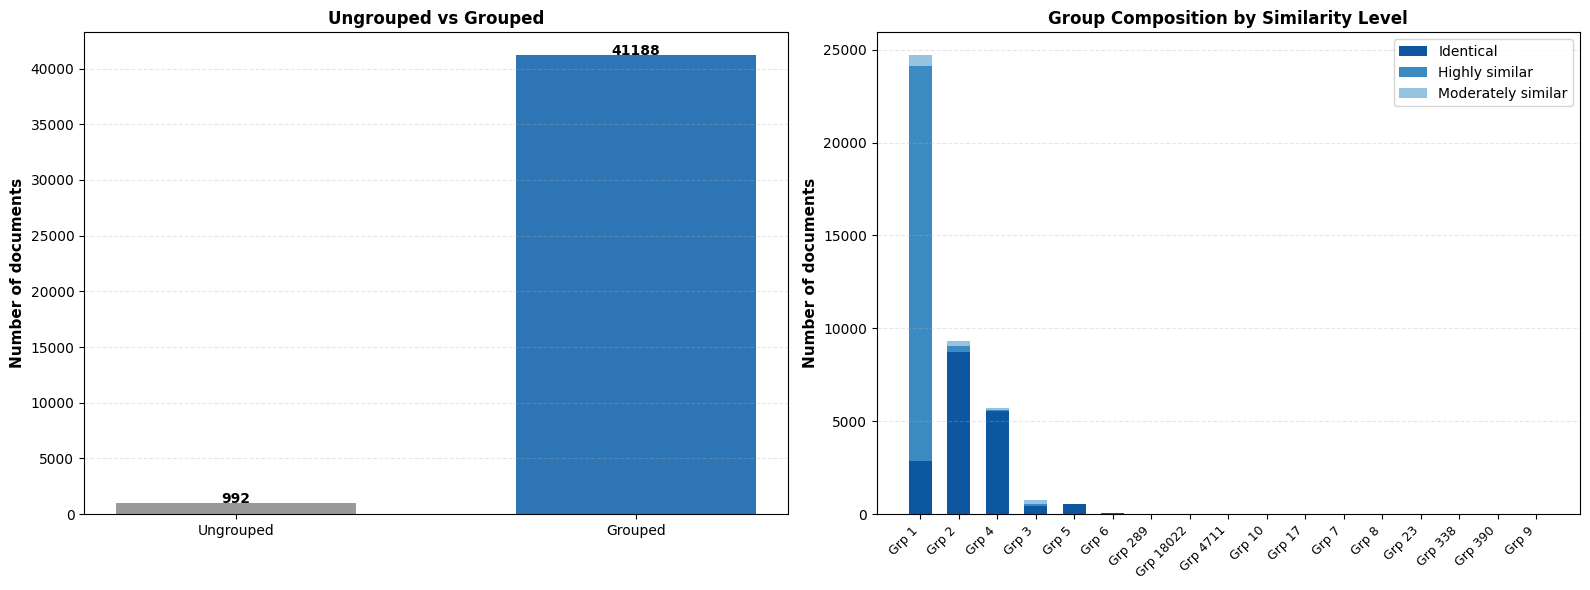

In [153]:
# Plot parameters
MIN_GROUP_SIZE_PLOT = 3
TOP_N_GROUPS = 40

# Prepare data for plotting
ungrouped = results[results['group_size'] == 1]
grouped = results[results['group_size'] > 1]

# Filter by size
large_groups = grouped[grouped['group_size'] >= MIN_GROUP_SIZE_PLOT]
large_group_ids = sorted(large_groups['group_id'].unique(),
                          key=lambda g: large_groups[large_groups['group_id'] == g].iloc[0]['group_size'],
                          reverse=True)[:TOP_N_GROUPS]

# Build plot data
plot_data = []
plot_labels = []

# Ungrouped bar
plot_labels.append('Ungrouped')
plot_data.append([len(ungrouped), 0, 0])

# Large groups
for gid in large_group_ids:
    g_data = grouped[grouped['group_id'] == gid]
    counts = g_data['group_label'].value_counts().to_dict()
    plot_labels.append(f"Grp {gid}")
    plot_data.append([
        counts.get('Grouped - Identical', 0),
        counts.get('Grouped - Highly similar', 0),
        counts.get('Grouped - Moderately similar', 0)
    ])

# Convert to arrays for stacking
plot_data = np.array(plot_data).T

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Colors - three shades of blue for the right plot
blue_colors = [plt.cm.Blues(0.85), plt.cm.Blues(0.65), plt.cm.Blues(0.4)]  # Dark, medium, light blue
bar_width = 0.6

# --- SUBPLOT 1: Ungrouped vs Grouped Summary ---
summary_labels = ['Ungrouped', 'Grouped']
summary_counts = [len(ungrouped), len(grouped)]
summary_colors = ['#999999', '#2E75B6']

ax1.bar(summary_labels, summary_counts, color=summary_colors, width=bar_width)
ax1.set_ylabel('Number of documents', fontsize=11, fontweight='bold')
ax1.set_title('Ungrouped vs Grouped', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(summary_counts):
    ax1.text(i, v + 10, str(v), ha='center', fontweight='bold')

# --- SUBPLOT 2: Group Composition (stacked bars) ---
group_plot_labels = plot_labels[1:]
group_plot_data = [row[1:] for row in plot_data]
x_pos = np.arange(len(group_plot_labels))

bottom = np.zeros(len(group_plot_labels))
labels_stack = ['Identical', 'Highly similar', 'Moderately similar']

for i, (row, label, color) in enumerate(zip(group_plot_data, labels_stack, blue_colors)):
    ax2.bar(x_pos, row, bar_width, label=label, bottom=bottom, color=color)
    bottom += np.array(row)

ax2.set_ylabel('Number of documents', fontsize=11, fontweight='bold')
#ax2.set_xlabel('Group (sorted by size)', fontsize=11, fontweight='bold')
ax2.set_title('Group Composition by Similarity Level', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(group_plot_labels, rotation=45, ha='right', fontsize=9)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()

# Save
plot_filename = f"{Path(filepath).stem}_grouped_plot.png"
plt.savefig(plot_filename, dpi=100, bbox_inches='tight')
print(f"✓ Saved plot: {plot_filename}")

plt.show()


Log-scale y-axis

✓ Saved plot: NOAA-NMFS-2023-0027_grouped_ylog_plot.png


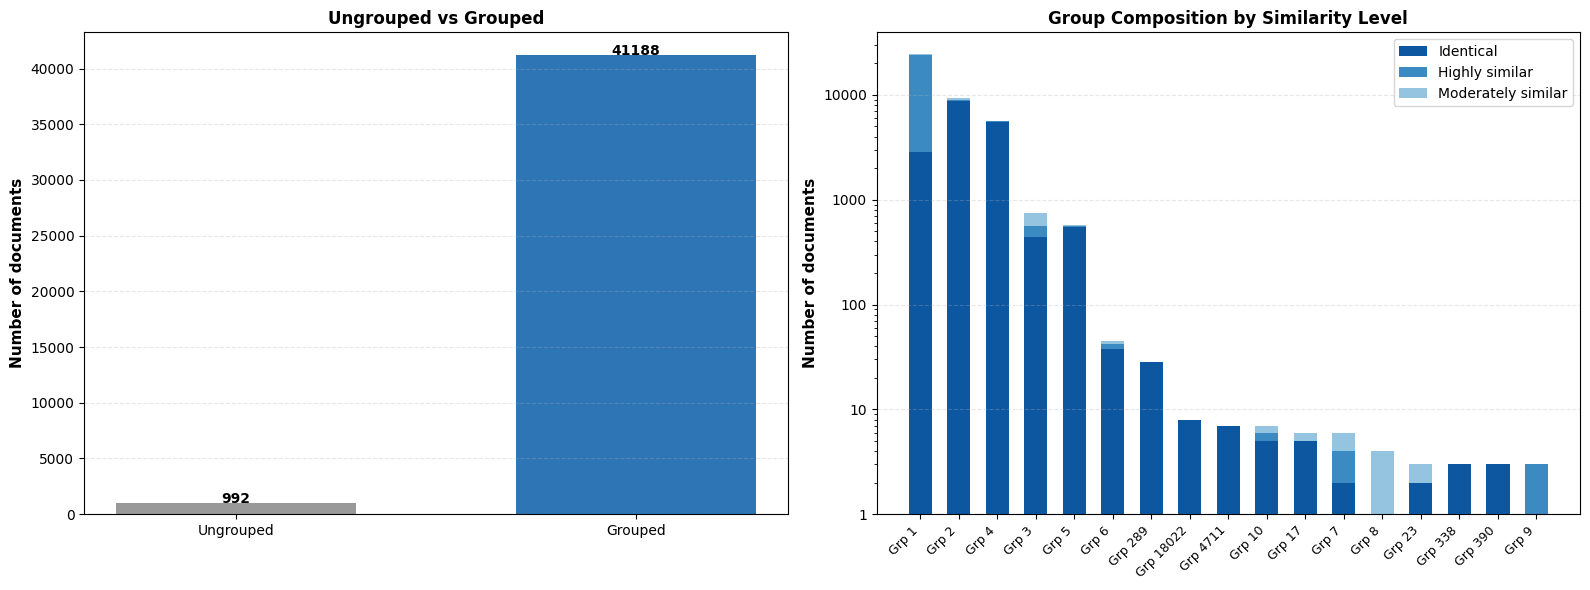

In [155]:
# Plot parameters
MIN_GROUP_SIZE_PLOT = 3
TOP_N_GROUPS = 40

# Prepare data for plotting
ungrouped = results[results['group_size'] == 1]
grouped = results[results['group_size'] > 1]

# Filter by size
large_groups = grouped[grouped['group_size'] >= MIN_GROUP_SIZE_PLOT]
large_group_ids = sorted(large_groups['group_id'].unique(),
                          key=lambda g: large_groups[large_groups['group_id'] == g].iloc[0]['group_size'],
                          reverse=True)[:TOP_N_GROUPS]

# Build plot data
plot_data = []
plot_labels = []

# Ungrouped bar
plot_labels.append('Ungrouped')
plot_data.append([len(ungrouped), 0, 0])

# Large groups
for gid in large_group_ids:
    g_data = grouped[grouped['group_id'] == gid]
    counts = g_data['group_label'].value_counts().to_dict()
    plot_labels.append(f"Grp {gid}")
    plot_data.append([
        counts.get('Grouped - Identical', 0),
        counts.get('Grouped - Highly similar', 0),
        counts.get('Grouped - Moderately similar', 0)
    ])

# Convert to arrays for stacking
plot_data = np.array(plot_data).T

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Colors - three shades of blue for the right plot
blue_colors = [plt.cm.Blues(0.85), plt.cm.Blues(0.65), plt.cm.Blues(0.4)]  # Dark, medium, light blue
bar_width = 0.6

# --- SUBPLOT 1: Ungrouped vs Grouped Summary ---
summary_labels = ['Ungrouped', 'Grouped']
summary_counts = [len(ungrouped), len(grouped)]
summary_colors = ['#999999', '#2E75B6']

ax1.bar(summary_labels, summary_counts, color=summary_colors, width=bar_width)
ax1.set_ylabel('Number of documents', fontsize=11, fontweight='bold')
ax1.set_title('Ungrouped vs Grouped', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(summary_counts):
    ax1.text(i, v + 10, str(v), ha='center', fontweight='bold')

# --- SUBPLOT 2: Group Composition (stacked bars) ---
group_plot_labels = plot_labels[1:]
group_plot_data = [row[1:] for row in plot_data]
x_pos = np.arange(len(group_plot_labels))

bottom = np.zeros(len(group_plot_labels))
labels_stack = ['Identical', 'Highly similar', 'Moderately similar']

for i, (row, label, color) in enumerate(zip(group_plot_data, labels_stack, blue_colors)):
    ax2.bar(x_pos, row, bar_width, label=label, bottom=bottom, color=color)
    bottom += np.array(row)

ax2.set_ylabel('Number of documents', fontsize=11, fontweight='bold')
#ax2.set_xlabel('Group (sorted by size)', fontsize=11, fontweight='bold')
ax2.set_title('Group Composition by Similarity Level', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(group_plot_labels, rotation=45, ha='right', fontsize=9)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_yscale('log')
ax2.set_yticks([1, 10, 100, 1000, 10000])
ax2.set_yticklabels(['1', '10', '100', '1000', '10000'])

plt.tight_layout()

# Save
plot_filename = f"{Path(filepath).stem}_grouped_ylog_plot.png"
plt.savefig(plot_filename, dpi=100, bbox_inches='tight')
print(f"✓ Saved plot: {plot_filename}")

plt.show()


# Interactive Explorer

Tool that lets you browse the groups of similar comments, select any two to compare side-by-side, and see their differences highlighted with a similarity score. Use to verify that the grouping makes sense before downloading the results.

*Need to add a cell to import previously processed datasheet*

In [156]:
build_explorer(results, comment_col, id_col)

Output()

# Export Results

In [ ]:
original_name = Path(filepath).stem
output_csv = f"{original_name}_grouped.csv"

# Select columns to export: original columns + new grouping columns
export_cols = list(df.columns) + [
    'group_id', 'group_size', 'group_label', 'is_identical',
    'J_to_rep', 'max_j_in_group', 'best_match_id',
    'is_group_rep', 'group_rep_id', 'family_id', 'family_size'
]
results[export_cols].to_csv(output_csv, index=False)

print(f"✓ Saved: {output_csv}")
print(f"  Rows: {len(results):,}")
print(f"  Original columns: {len(df.columns)}")
print(f"  New grouping columns: {len(export_cols) - len(df.columns)}")
print(f"  Total columns: {len(export_cols)}")

if IN_COLAB:
    files.download(output_csv)
else:
    print(f"  File saved to: {Path(output_csv).absolute()}")